In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7" "seaborn>=0.13" "scikit-learn>=1.3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
from scipy.optimize import minimize
from scipy.special import gammaln
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 폰트 목록에는 그 설치가 반영되지 않으므로 addfont 로
#  등록해야 이름이 보인다(등록하지 않으면 DejaVu Sans 로 대체되어 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 축소되지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150      # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True                            # 여백은 tight_layout 이 자동 조정
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     # 위 테두리·오른쪽 테두리·격자를 제거해 데이터만 남긴다
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 4개가 함께 쓰는 색 — 사전=남색, 우도=파랑, 사후·강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3", "참값": "#757575"}
FIG_W = 10.0     # 캔버스 폭은 4개 모두 이 값으로 고정하고 높이만 그림마다 조절한다

print("사용 폰트:", FONT,
      "| 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다")

사용 폰트: NanumGothic | 색 팔레트 준비 완료 — 채점 셀은 LMS 가 자동으로 준비합니다


In [2]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 변수를 직접 만듭니다
from sklearn.datasets import fetch_openml

# freMTPL2freq — 프랑스 자동차보험 계약별 사고 빈도 (678,013 x 12). OpenML 에서 바로 내려받습니다
df = fetch_openml(data_id=41214, as_frame=True).frame
df["IDpol"] = df["IDpol"].astype(int)
for c in ["Area", "VehBrand", "VehGas", "Region"]:
    df[c] = df[c].astype(str).str.strip("'").astype("category")

# 어제 정해 5일 내내 고정하는 전처리 규칙 2개
df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)   # 사고 5건 이상은 극소수라 상한 4 로 절사
df["Exposure"] = df["Exposure"].clip(upper=1.0)           # 노출은 1년 상한

y = df["ClaimNb"].to_numpy(dtype=float)      # 쓸 변수 1 — 계약별 사고 건수 (단위 건)
E = df["Exposure"].to_numpy(dtype=float)     # 쓸 변수 2 — 계약별 노출 (단위 년)


def poisson_nll(lam):                        # 쓸 변수 3 — 이론에서 만든 노출 보정 포아송의 음의 로그우도
    """lam 은 숫자 하나 또는 길이 1 배열. 최소화용이라 로그우도에 마이너스를 붙여 돌려줍니다"""
    lam = float(np.atleast_1d(lam)[0])
    if lam <= 0:
        return 1e12                          # 범위 밖 후보에는 큰 벌점
    return -np.sum(y * np.log(lam * E) - lam * E - gammaln(y + 1))


print("행 x 열 :", df.shape, "| 결측치 총합 :", int(df.isna().sum().sum()))
print(df[["IDpol", "ClaimNb", "Exposure", "Area", "VehBrand", "Region"]].head())
print("쓸 수 있는 이름 : y (사고 건수, 건) · E (노출, 년) · poisson_nll(lam) (음의 로그우도)")

행 x 열 : (678013, 12) | 결측치 총합 : 0
   IDpol  ClaimNb  Exposure Area VehBrand Region
0      1        1      0.10    D      B12    R82
1      3        1      0.77    D      B12    R82
2      5        1      0.75    B      B12    R22
3     10        1      0.09    B      B12    R72
4     11        1      0.84    B      B12    R72
쓸 수 있는 이름 : y (사고 건수, 건) · E (노출, 년) · poisson_nll(lam) (음의 로그우도)


lam_hat = 0.100615 건/년
total_exposure = 358360.1 년
converged = True, iterations = 13


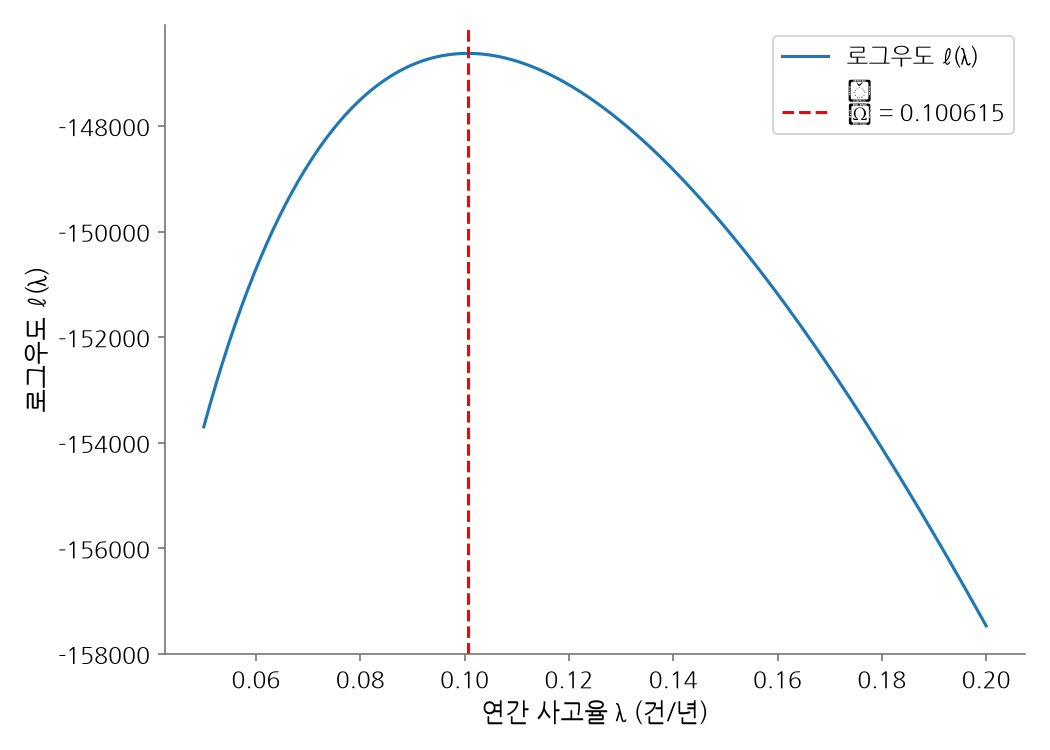

In [3]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
만들 것

연간 사고율 λ̂ — 단위 건/년 · 소수점 아래 6자리 · poisson_nll 을 수치 최적화로 가장 작게 만드는 사고율
▸음의 로그우도(NLL) 는 로그우도에 마이너스를 곱해 최댓값 찾기를 최솟값 찾기로 바꾼 값입니다. 부호만 바꾸었으므로 최적해의 가로축 위치, 곧 λ 는 변하지 않습니다

총 노출 — 단위 년 · 소수점 아래 1자리 · E 를 전부 더한 값이고, 1번 나눗셈의 분모에 해당합니다

추가할 한 행 — 최적화의 수렴 여부와 반복 횟수
▸채점 대상은 아니고, 통과 뒤 열리는 완성본과 대조할 항목입니다

그래프 한 장 — 가로축은 후보 연간 사고율 0.05 ～ 0.20, 세로축은 로그우도인 선 그래프
▸곡선 : 후보를 촘촘히 나열한 로그우도 곡선 하나 — poisson_nll 에 마이너스를 곱한 값입니다
▸세로선 : 1번에서 찾은 사고율 위치에 세로축 아래 끝부터 위 끝까지 곧은 선 하나 — 곡선은 로그우도 선 한 개뿐이고, 이 세로선은 곡선으로 세지 않습니다
▸가로축 이름 : 「연간 사고율 λ (건/년)」
▸세로축 이름 : 「로그우도 ℓ(λ)」

출력 형식 — 「이름 = 값 단위」 형식으로 1행씩 print 합니다. 그래프는 한 장입니다.

 y · E · poisson_nll 은 이미 있으니 다시 만들지 마세요
 
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

result = minimize_scalar(poisson_nll, bounds=(0.001, 1.0), method="bounded")
lam_hat = result.x
total_exposure = E.sum()

print(f"lam_hat = {lam_hat:.6f} 건/년")
print(f"total_exposure = {total_exposure:.1f} 년")
print(f"converged = {result.success}, iterations = {result.nfev}")

lam_grid = np.linspace(0.05, 0.20, 500)
loglik = [-poisson_nll(lam) for lam in lam_grid]

plt.figure(figsize=(7, 5))
plt.plot(lam_grid, loglik, label="로그우도 ℓ(λ)")
plt.axvline(lam_hat, color="red", linestyle="--", label=f"λ̂ = {lam_hat:.6f}")
plt.xlabel("연간 사고율 λ (건/년)")
plt.ylabel("로그우도 ℓ(λ)")
plt.legend()
plt.show()

In [4]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 이 미션만 따로 열어도 이 셀부터 실행하면 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)       # 어제 정한 전처리 규칙 2개 — 미션 1 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)

group_keys = ["Region", "VehBrand"]                           # 쓸 변수 1 — 세그먼트 기준 열 2개
lam_all = float(df["ClaimNb"].sum() / df["Exposure"].sum())   # 쓸 변수 2 — 전체 계약의 연간 사고율 (건/년), 대조용
claims_all = int(df["ClaimNb"].sum())                         # 쓸 변수 3 — 원본 전체 사고 건수 (건), 대조용

print("세그먼트 축 :", group_keys, "|",
      f'지역 {df["Region"].nunique()}개 x 브랜드 {df["VehBrand"].nunique()}개'
      " — 계약이 실제로 있는 조합이 몇 개인지는 표를 만들어 보면 나옵니다")
print(f"대조용 — 전체 계약 사고율 lam_all : {lam_all:.6f} 건/년"
      f" | 원본 사고 합 claims_all : {claims_all:,} 건")
print("쓸 수 있는 이름 :  df · group_keys · lam_all · claims_all")

세그먼트 축 : ['Region', 'VehBrand'] | 지역 22개 x 브랜드 11개 — 계약이 실제로 있는 조합이 몇 개인지는 표를 만들어 보면 나옵니다
대조용 — 전체 계약 사고율 lam_all : 0.100614 건/년 | 원본 사고 합 claims_all : 36,056 건
쓸 수 있는 이름 :  df · group_keys · lam_all · claims_all


세그먼트 수 : 242 개
가장 높은 세그먼트의 사고율 : 0.309191 건/년 (R43 × B4) | 가장 낮은 세그먼트 0.000000 | 사고율 0 인 세그먼트 9 개


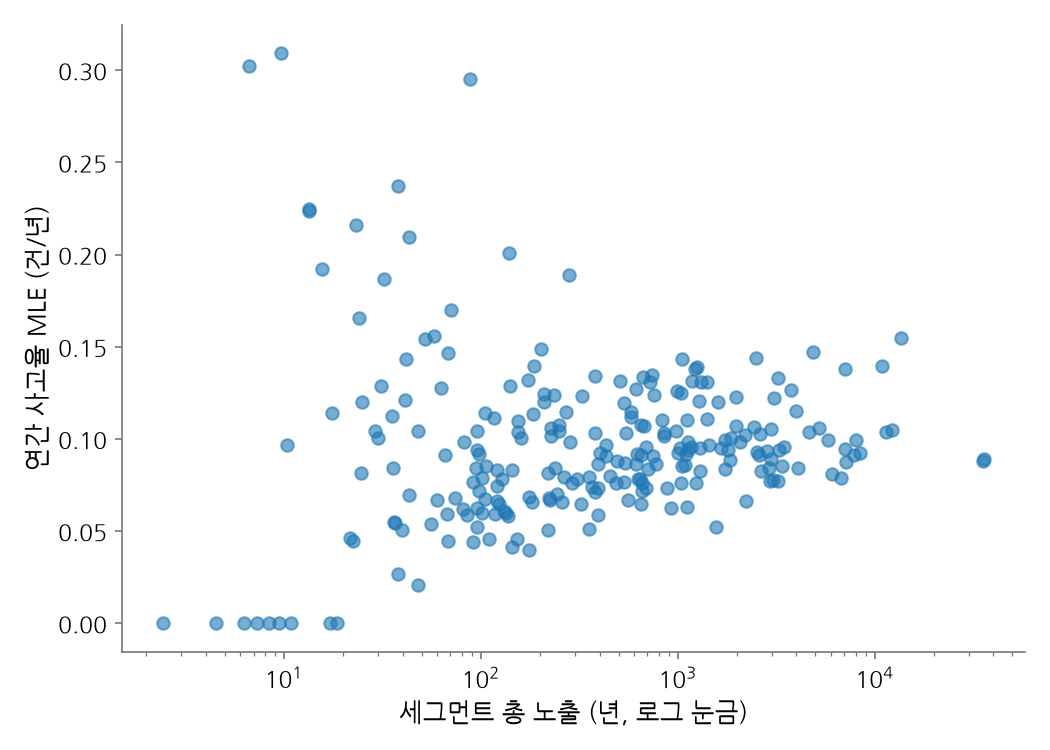

In [5]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 AI 튜터가 「여기부터 AI 코드」 아래를 다시 씁니다.
seg_fine = (df.groupby(group_keys, observed=True)
              .agg(n=("IDpol", "size"), claims=("ClaimNb", "sum"), exposure=("Exposure", "sum"))
              .reset_index())
seg_fine["lam_mle"] = seg_fine["claims"] / seg_fine["exposure"]

print(f"세그먼트 수 : {len(seg_fine)} 개")

top_row = seg_fine.loc[seg_fine["lam_mle"].idxmax()]
top_name = f"{top_row['Region']} × {top_row['VehBrand']}"
print(f"가장 높은 세그먼트의 사고율 : {top_row['lam_mle']:.6f} 건/년 ({top_name})"
      f" | 가장 낮은 세그먼트 {seg_fine['lam_mle'].min():.6f}"
      f" | 사고율 0 인 세그먼트 {int((seg_fine['lam_mle'] == 0).sum())} 개")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(seg_fine["exposure"], seg_fine["lam_mle"], alpha=0.6)
ax.set_xscale("log")
ax.set_xlabel("세그먼트 총 노출 (년, 로그 눈금)")
ax.set_ylabel("연간 사고율 MLE (건/년)")
plt.show()

In [6]:
# 미션 3 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 3 에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 이 미션만 따로 열어도 이 셀부터 실행하면 됩니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)       # 어제 정한 전처리 규칙 2개 — 미션 1 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)

group_keys = ["Region", "VehBrand"]                             # 쓸 변수 1 — 세그먼트 기준 열 2개
seg_fine = (df.groupby(group_keys, observed=True)               # 쓸 변수 2 — 242개 세그먼트 MLE 요율표
              .agg(n=("IDpol", "size"), claims=("ClaimNb", "sum"),
                   exposure=("Exposure", "sum"))
              .reset_index())
seg_fine["lam_mle"] = seg_fine["claims"] / seg_fine["exposure"]
lam_all = float(df["ClaimNb"].sum() / df["Exposure"].sum())     # 쓸 변수 3 — 전체 계약의 연간 사고율 (건/년)
beta_0 = 100.0                                                  # 쓸 변수 4 — 사전분포의 유효 노출 = 가상 노출 (년)
alpha_0 = 1 + lam_all * beta_0                                  # 쓸 변수 5 — 최빈값을 전체 계약 사고율에 맞춘 alpha
watch = seg_fine[(seg_fine["Region"] == "R21")                  # 쓸 변수 6 — 미션 3 에서 정한 확인 대상 세그먼트 한 행
                 & (seg_fine["VehBrand"] == "B11")]

print(f"세그먼트 {len(seg_fine)}개 | 컬럼 {list(seg_fine.columns)}")
print(f"전체 계약 사고율 lam_all : {lam_all:.6f} 건/년")
print(f"사전 Gamma(alpha_0={alpha_0:.2f}, beta_0={beta_0:.0f})"
      f" — 이 사전분포의 최빈값 (alpha_0 - 1) / beta_0 = {(alpha_0 - 1) / beta_0:.6f} 건/년")
print(f"확인 대상 세그먼트 watch : {watch.iloc[0]['Region']} x {watch.iloc[0]['VehBrand']}"
      f" | 계약 {int(watch.iloc[0]['n'])}건 · 사고 {int(watch.iloc[0]['claims'])}건"
      f" · 노출 {float(watch.iloc[0]['exposure']):.2f}년 — 표의 한 행입니다")
print("쓸 수 있는 이름 :  seg_fine · watch · lam_all · alpha_0 · beta_0")

세그먼트 242개 | 컬럼 ['Region', 'VehBrand', 'n', 'claims', 'exposure', 'lam_mle']
전체 계약 사고율 lam_all : 0.100614 건/년
사전 Gamma(alpha_0=11.06, beta_0=100) — 이 사전분포의 최빈값 (alpha_0 - 1) / beta_0 = 0.100614 건/년
확인 대상 세그먼트 watch : R21 x B11 | 계약 12건 · 사고 2건 · 노출 6.62년 — 표의 한 행입니다
쓸 수 있는 이름 :  seg_fine · watch · lam_all · alpha_0 · beta_0


R21×B11 MAP = 0.113125 건/년
242개 세그먼트 MAP 최솟값 = 0.055063 건/년
R21×B11 lam_mle = 0.302115 건/년 | lam_mle 0인 세그먼트 수 = 9 개


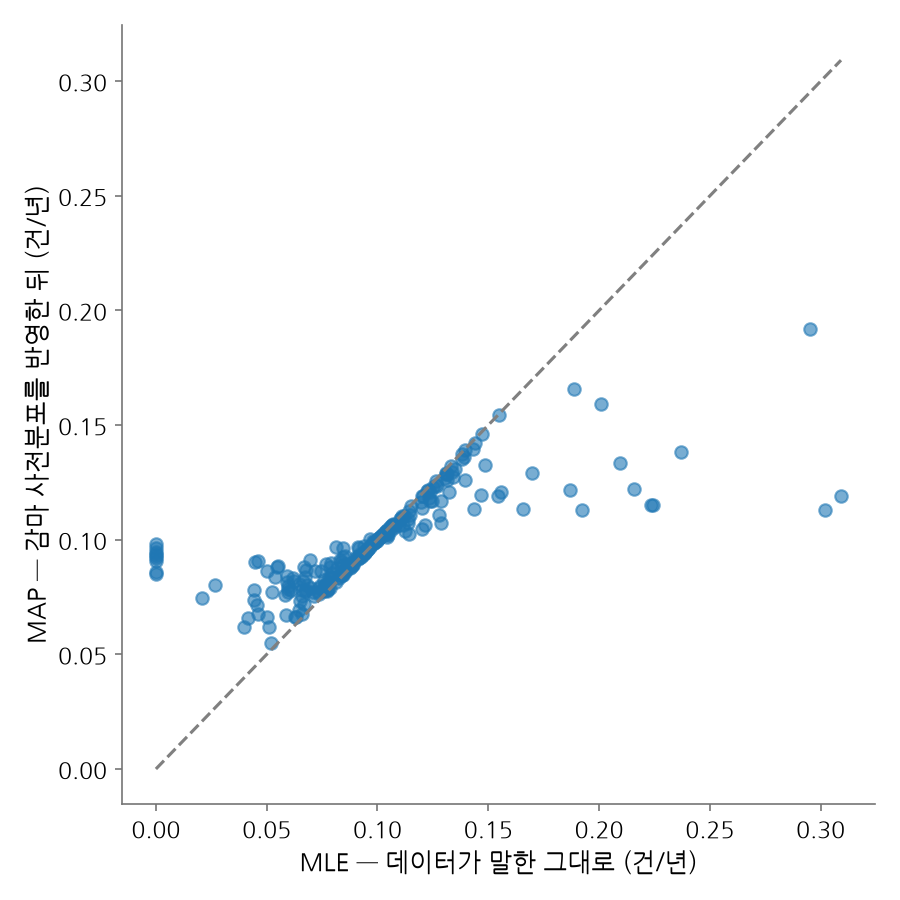

In [7]:
# 미션 3 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
만들 것

R21 × B11 세그먼트의 MAP — 단위 건/년 · 소수점 아래 6자리 · watch 한 행에 아래 MAP 공식을 넣은 값

242개 세그먼트 MAP 의 최솟값 — 단위 건/년 · 소수점 아래 6자리 · 242개 전부에 MAP 를 적용한 뒤 가장 작은 값
▸이 값이 0 보다 크면 사고율이 0 으로 계산되던 세그먼트가 하나도 남지 않았다는 뜻입니다

추가할 한 행 — 같은 세그먼트의 lam_mle 와, lam_mle 가 0 이던 세그먼트 수
▸채점 대상은 아니고, 통과 뒤 열리는 완성본과 대조할 항목입니다

그래프 한 장 — 가로축은 세그먼트의 MLE, 세로축은 그 세그먼트의 MAP 인 산점도
▸점 : 세그먼트 하나에 점 하나, 모두 242개
▸대각선 : 두 값이 같은 지점을 잇는 y=x 선 하나 — 0 부터 MLE 최댓값까지 긋습니다
▸가로축 이름 : 「MLE — 데이터가 말한 그대로 (건/년)」
▸세로축 이름 : 「MAP — 감마 사전분포를 반영한 뒤 (건/년)」

출력 형식 — 「이름 = 값 단위」 형식으로 1행씩 print 합니다. 표를 통째로 출력하면 채점이 어느 값을 읽을지 고르지 못합니다. 그래프는 한 장입니다.

쓸 공식 — 사후분포의 최빈값(mode, MAP)

seg_fine · watch · alpha_0 · beta_0 은 이미 있으니 다시 만들지 마세요

"""
# --- 여기부터 AI 코드 ---
map_watch = (alpha_0 + watch["claims"].iloc[0] - 1) / (beta_0 + watch["exposure"].iloc[0])
seg_fine["lam_map"] = (alpha_0 + seg_fine["claims"] - 1) / (beta_0 + seg_fine["exposure"])

print(f"R21×B11 MAP = {map_watch:.6f} 건/년")
print(f"242개 세그먼트 MAP 최솟값 = {seg_fine['lam_map'].min():.6f} 건/년")
print(f"R21×B11 lam_mle = {watch['lam_mle'].iloc[0]:.6f} 건/년 | lam_mle 0인 세그먼트 수 = {int((seg_fine['lam_mle'] == 0).sum())} 개")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(seg_fine["lam_mle"], seg_fine["lam_map"], alpha=0.6)
mle_max = seg_fine["lam_mle"].max()
ax.plot([0, mle_max], [0, mle_max], color="gray", linestyle="--")
ax.set_xlabel("MLE — 데이터가 말한 그대로 (건/년)")
ax.set_ylabel("MAP — 감마 사전분포를 반영한 뒤 (건/년)")
plt.show()

In [8]:
# 과제 · 준비 — 읽고 실행만 합니다. 이 셀이 과제에 쓸 변수를 직접 만듭니다
if "df" not in globals():                                       # 앞 미션을 안 돌렸으면 맨 위 설치 셀과 이 셀을 실행합니다
    from sklearn.datasets import fetch_openml                    # (앞 미션을 이미 돌렸으면 통째로 건너뜁니다)
    df = fetch_openml(data_id=41214, as_frame=True).frame
    df["IDpol"] = df["IDpol"].astype(int)
    for c in ["Area", "VehBrand", "VehGas", "Region"]:
        df[c] = df[c].astype(str).str.strip("'").astype("category")
    df["ClaimNb"] = df["ClaimNb"].astype(int).clip(upper=4)       # 어제 정한 전처리 규칙 2개 — 미션 1 과 같습니다
    df["Exposure"] = df["Exposure"].clip(upper=1.0)

df["HasClaim"] = (df["ClaimNb"] > 0).astype(int)          # 사고를 한 건이라도 냈으면 1, 아니면 0
p_global = float(df["HasClaim"].mean())                   # 쓸 변수 1 — 전체 계약의 사고 경험률 (비율)
nu = 100.0                                                # 쓸 변수 2 — 사전분포의 유효 표본 수 = 가상 계약 수 (건)

# 세그먼트 집계와 MLE 까지는 완성해 두었습니다 (미션 2·3 과 같은 Region x VehBrand 242개)
seg_bin = (df.groupby(["Region", "VehBrand"], observed=True)
             .agg(n=("HasClaim", "size"), s=("HasClaim", "sum"))
             .reset_index())
seg_bin["p_mle"] = seg_bin["s"] / seg_bin["n"]

reg_bin = (df.groupby("Region", observed=True)            # 쓸 변수 3 — 지역 22개 표 (세그먼트 대신 지역)
             .agg(n=("HasClaim", "size"), s=("HasClaim", "sum"))
             .reset_index())
reg_bin["p_mle"] = reg_bin["s"] / reg_bin["n"]
rng = np.random.default_rng(0)                            # 쓸 변수 4 — 표본추출의 난수 시드를 고정합니다

print(f"세그먼트 {len(seg_bin)}개 | 컬럼 {list(seg_bin.columns)}")
print(f"전체 계약의 사고 경험률 p_global : {p_global:.6f} (비율)"
      f" | 사전분포의 유효 표본 수 nu = {nu:.0f} 건")
print(f"사고 경험률이 0 으로 계산된 세그먼트 : {int((seg_bin['p_mle'] == 0).sum())} 개")
print(f"전체 계약 {int(seg_bin['n'].sum()):,}건 — 242개 세그먼트의 계약 수를 모두 더한 값입니다")
print("\n[계약 수가 가장 적은 세그먼트 8개 — 지금은 MLE 만]")
print(seg_bin.nsmallest(8, "n").round(4).to_string(index=False))
_two_regions = reg_bin.set_index("Region")
print(f"\n지역 {len(reg_bin)}개"
      f" | R43 계약 {int(_two_regions.loc['R43', 'n']):,}건 중 사고 계약 {int(_two_regions.loc['R43', 's'])}건"
      f" · R42 계약 {int(_two_regions.loc['R42', 'n']):,}건 중 {int(_two_regions.loc['R42', 's'])}건")
print("\n쓸 수 있는 이름 :  seg_bin (n · s · p_mle 열) · p_global · nu"
      " · reg_bin (n · s · p_mle 열) · rng")

세그먼트 242개 | 컬럼 ['Region', 'VehBrand', 'n', 's', 'p_mle']
전체 계약의 사고 경험률 p_global : 0.050235 (비율) | 사전분포의 유효 표본 수 nu = 100 건
사고 경험률이 0 으로 계산된 세그먼트 : 9 개
전체 계약 678,013건 — 242개 세그먼트의 계약 수를 모두 더한 값입니다

[계약 수가 가장 적은 세그먼트 8개 — 지금은 MLE 만]
Region VehBrand  n  s  p_mle
   R42      B14  6  0 0.0000
   R21      B14  8  0 0.0000
   R43      B11  8  0 0.0000
   R21      B11 12  2 0.1667
   R43      B10 15  0 0.0000
   R94      B14 18  0 0.0000
   R94      B10 19  0 0.0000
   R43      B14 20  0 0.0000

지역 22개 | R43 계약 1,326건 중 사고 계약 54건 · R42 계약 2,200건 중 124건

쓸 수 있는 이름 :  seg_bin (n · s · p_mle 열) · p_global · nu · reg_bin (n · s · p_mle 열) · rng


n_top_mle = 239 건
n_top_map = 8879 건
n_refund = 643953 건
prob_r42_gt_r43 = 0.9767
R21×B11 MAP = 0.062710 비율
242개 세그먼트 MAP 최솟값 = 0.023951 비율
p_R42-p_R43 95% 신용구간 = [0.000196, 0.028332]


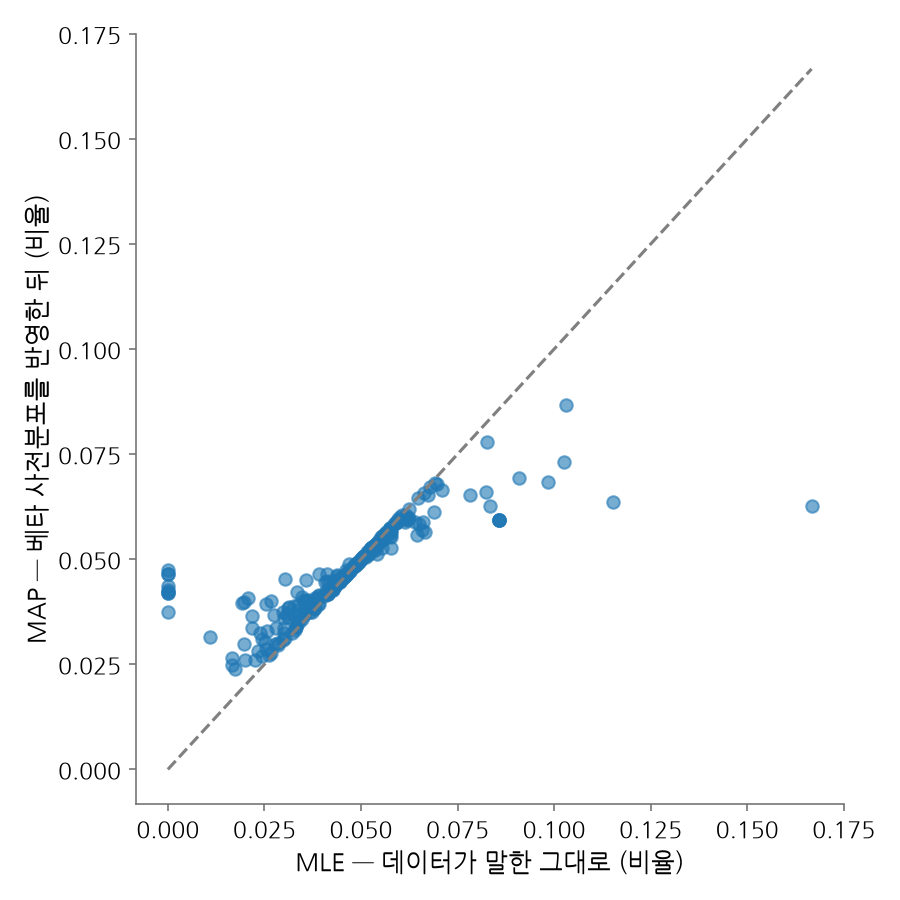

In [9]:
# 과제 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
MLE 로 고른 상위 열 세그먼트의 계약 수 — 단위 건 · 정수
▸무사고율(= 1 − 사고 경험률)이 높은 순으로 p_mle 로 세그먼트 10개를 골라 그 n 을 더한 값입니다

MAP 로 고른 상위 열 세그먼트의 계약 수 — 단위 건 · 정수
▸같은 일을 MAP 열로 한 번 더 합니다. 2개 값이 크게 다르면 명단을 정하는 것이 데이터가 아니라 추정 방법이라는 뜻입니다
▸MAP 열은 아래 「쓸 공식 — 베타분포와 MAP」의 MAP 공식으로 만듭니다

무사고 환급 대상 계약 수 — 단위 건 · 정수
▸p_global 을 1 에서 뺀 무사고 비율에 전체 계약 수를 곱합니다. 마케팅팀이 실제로 물어본 숫자가 이 값 1개입니다
▸p_global 은 계약마다 길이가 다른 관측 기간, 곧 계약당 평균 0.53년 동안 사고를 겪은 비율입니다. 1년 갱신 주기로 환산하려면 미션 1 에서 구한 전체 계약 사고율 λ 를 지수에 두고 1−e^−λ를 사고 비율로 계산해야 하며, 그러면 대상이 약 3만 건 감소합니다. 출력하는 이름은 채점이 읽으므로 그대로 두고, 환산값은 아래 답신의 결론에 함께 적습니다

R42 가 R43 보다 높을 확률 — 단위 확률 · 소수점 아래 4자리
▸높다는 것은 사고 경험률 p 가 크다는 뜻이고, 이 확률은 데이터를 고정하고 모수 p 를 무작위로 두는 사후확률입니다

추가할 3개 행 — 채점 대상은 아니고, 통과 뒤 열리는 완성본과 대조할 항목입니다
▸R21 × B11 세그먼트의 MAP, 단위 비율 · 소수점 아래 6자리 — 242개 표에서 지역 R21 · 브랜드 B11 행을 골라냅니다
▸242개 세그먼트 MAP 의 최솟값, 단위 비율 — 브리핑의 위험 항목 근거입니다
▸두 지역의 사고 경험률 차이 p_R42−p_R43의 95% 신용구간, 단위 비율 — 확률은 차이의 방향을, 신용구간은 차이의 크기까지 나타냅니다

그래프 한 장 — 가로축은 세그먼트의 MLE, 세로축은 그 세그먼트의 MAP 인 산점도
▸점 : 세그먼트 하나에 점 하나, 모두 242개
▸대각선 : 가로축 값과 세로축 값이 같은 지점을 잇는 y=x 선 하나, 0 부터 MLE 최댓값까지 곧게 긋습니다
▸가로축 이름 : 「MLE — 데이터가 말한 그대로 (비율)」
▸세로축 이름 : 「MAP — 베타 사전분포를 반영한 뒤 (비율)」

출력 형식 — 값 4개를 「이름 = 값 단위」 형식으로 1행씩 print 합니다. 그래프는 한 장입니다.

두 지역 비교 — 고정 규칙 4개
-두 지역의 사후분포는 이 과제가 정한 그 베타 사전분포를 지역 표 reg_bin 에 그대로 적용해 만듭니다.
-확률은 두 사후분포에서 표본 10만 쌍을 추출해 R42 쪽이 더 큰 표본의 비율을 계산합니다(이론의 「5. 두 집단 비교와 사고 건수」에서 쓴 방법 2).
-표본추출의 난수 시드(seed) 는 「준비 셀」이 rng 로 고정해 둡니다. 난수 시드는 난수 생성이 매번 같은 값을 생성하도록 고정해 두는 시작값이라 여러분이 따로 정하지 않습니다.
-구간은 같은 표본 10만 쌍에서 두 지역 값의 차이를 계산한 뒤 2.5%·97.5% 백분위수로 냅니다. 신용구간은 사후분포에서 모수의 값이 95% 확률로 포함되는 구간입니다. 1편의 신뢰구간 95% 는 표집을 반복할 때 구간이 참값을 포함하는 비율이라, 무작위로 두는 대상이 다릅니다.

seg_bin · p_global · nu · reg_bin · rng 는 이미 있으니 다시 만들지 마세요.

쓸 공식 — 베타분포와 MAP
포아송분포의 켤레 사전분포가 감마분포였듯, 사고 유무의 켤레 사전분포는 베타분포입니다. 베타분포는 0 과 1 사이에서만 확률밀도가 정의되는 분포족이고, 모수 2개  알파_b, β_b로 모양이 정해집니다. 아래 첨자 b 는 「베타 사전분포의 모수」라는 표시로, 미션 3 의 감마 사전분포 모수 α_0, β_0와 뜻이 다른 모수이므로 기호를 구분해 씁니다.


"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

alpha_b = 1 + nu * p_global
beta_b = 1 + nu * (1 - p_global)

seg_bin["p_map"] = (alpha_b + seg_bin["s"] - 1) / (nu + seg_bin["n"])

n_top_mle = seg_bin.nsmallest(10, "p_mle")["n"].sum()
n_top_map = seg_bin.nsmallest(10, "p_map")["n"].sum()

total_n = seg_bin["n"].sum()
n_refund = int(round((1 - p_global) * total_n))

r42 = reg_bin.loc[reg_bin["Region"] == "R42"].iloc[0]
r43 = reg_bin.loc[reg_bin["Region"] == "R43"].iloc[0]

alpha_r42 = alpha_b + r42["s"]
beta_r42 = beta_b + (r42["n"] - r42["s"])
alpha_r43 = alpha_b + r43["s"]
beta_r43 = beta_b + (r43["n"] - r43["s"])

samples_r42 = rng.beta(alpha_r42, beta_r42, size=100_000)
samples_r43 = rng.beta(alpha_r43, beta_r43, size=100_000)

prob_r42_gt_r43 = (samples_r42 > samples_r43).mean()
diff = samples_r42 - samples_r43
ci_low, ci_high = np.percentile(diff, [2.5, 97.5])

print(f"n_top_mle = {n_top_mle} 건")
print(f"n_top_map = {n_top_map} 건")
print(f"n_refund = {n_refund} 건")
print(f"prob_r42_gt_r43 = {prob_r42_gt_r43:.4f}")

watch_map = seg_bin.loc[(seg_bin["Region"] == "R21") & (seg_bin["VehBrand"] == "B11"), "p_map"].iloc[0]
print(f"R21×B11 MAP = {watch_map:.6f} 비율")
print(f"242개 세그먼트 MAP 최솟값 = {seg_bin['p_map'].min():.6f} 비율")
print(f"p_R42-p_R43 95% 신용구간 = [{ci_low:.6f}, {ci_high:.6f}]")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(seg_bin["p_mle"], seg_bin["p_map"], alpha=0.6)
mle_max = seg_bin["p_mle"].max()
ax.plot([0, mle_max], [0, mle_max], color="gray", linestyle="--")
ax.set_xlabel("MLE — 데이터가 말한 그대로 (비율)")
ax.set_ylabel("MAP — 베타 사전분포를 반영한 뒤 (비율)")
plt.show()

In [10]:
total_n

np.int64(678013)

In [11]:
n_refund/total_n*100

np.float64(94.97649750078538)

In [12]:
1 - np.exp(-lam_hat)

np.float64(0.09571888918173821)